Name = sharvil Vichare
Roll no = B39
PRN = 2324000814


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image

In [ ]:
image_path="/content/flower-729510_1280.jpg"

In [ ]:
img = cv2.imread(image_path)

Image Negative


In [ ]:
img_negative = 255 - img
img_negative

array([[[201, 231, 236],
        [201, 231, 236],
        [201, 231, 236],
        ...,
        [205, 234, 239],
        [205, 234, 239],
        [205, 234, 239]],

       [[201, 231, 236],
        [201, 231, 236],
        [201, 231, 236],
        ...,
        [205, 234, 239],
        [205, 234, 239],
        [205, 234, 239]],

       [[201, 231, 236],
        [201, 231, 236],
        [201, 231, 236],
        ...,
        [205, 234, 239],
        [205, 234, 239],
        [205, 234, 239]],

       ...,

       [[167, 185, 216],
        [167, 185, 216],
        [167, 185, 216],
        ...,
        [202, 228, 240],
        [202, 228, 240],
        [202, 228, 240]],

       [[167, 185, 216],
        [167, 185, 216],
        [167, 185, 216],
        ...,
        [202, 228, 240],
        [202, 228, 240],
        [202, 228, 240]],

       [[167, 185, 216],
        [168, 186, 217],
        [168, 186, 217],
        ...,
        [201, 227, 239],
        [201, 227, 239],
        [201, 227, 239]]

array([[[54, 24, 19],
        [54, 24, 19],
        [54, 24, 19],
        ...,
        [50, 21, 16],
        [50, 21, 16],
        [50, 21, 16]],

       [[54, 24, 19],
        [54, 24, 19],
        [54, 24, 19],
        ...,
        [50, 21, 16],
        [50, 21, 16],
        [50, 21, 16]],

       [[54, 24, 19],
        [54, 24, 19],
        [54, 24, 19],
        ...,
        [50, 21, 16],
        [50, 21, 16],
        [50, 21, 16]],

       ...,

       [[88, 70, 39],
        [88, 70, 39],
        [88, 70, 39],
        ...,
        [53, 27, 15],
        [53, 27, 15],
        [53, 27, 15]],

       [[88, 70, 39],
        [88, 70, 39],
        [88, 70, 39],
        ...,
        [53, 27, 15],
        [53, 27, 15],
        [53, 27, 15]],

       [[88, 70, 39],
        [87, 69, 38],
        [87, 69, 38],
        ...,
        [54, 28, 16],
        [54, 28, 16],
        [54, 28, 16]]], dtype=uint8)

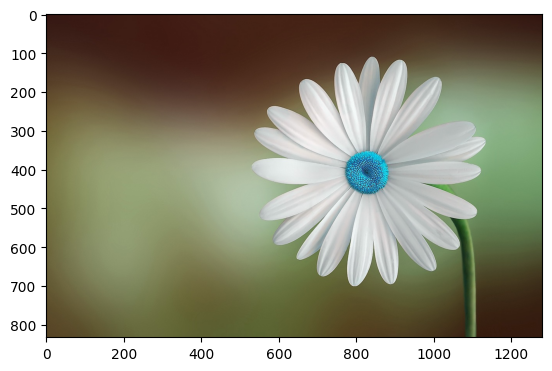

In [ ]:
plt.imshow(img)
img

Contrast Stretching


In [ ]:
r_min = np.min(img)
r_max = np.max(img)

In [ ]:
i_min=0
i_max=205

In [ ]:
stretching_img = (img - r_min) / (i_max - i_min) * 255

In [ ]:
stretching_img

array([[[ 67.17073171,  29.85365854,  23.63414634],
        [ 67.17073171,  29.85365854,  23.63414634],
        [ 67.17073171,  29.85365854,  23.63414634],
        ...,
        [ 62.19512195,  26.12195122,  19.90243902],
        [ 62.19512195,  26.12195122,  19.90243902],
        [ 62.19512195,  26.12195122,  19.90243902]],

       [[ 67.17073171,  29.85365854,  23.63414634],
        [ 67.17073171,  29.85365854,  23.63414634],
        [ 67.17073171,  29.85365854,  23.63414634],
        ...,
        [ 62.19512195,  26.12195122,  19.90243902],
        [ 62.19512195,  26.12195122,  19.90243902],
        [ 62.19512195,  26.12195122,  19.90243902]],

       [[ 67.17073171,  29.85365854,  23.63414634],
        [ 67.17073171,  29.85365854,  23.63414634],
        [ 67.17073171,  29.85365854,  23.63414634],
        ...,
        [ 62.19512195,  26.12195122,  19.90243902],
        [ 62.19512195,  26.12195122,  19.90243902],
        [ 62.19512195,  26.12195122,  19.90243902]],

       ...,

      

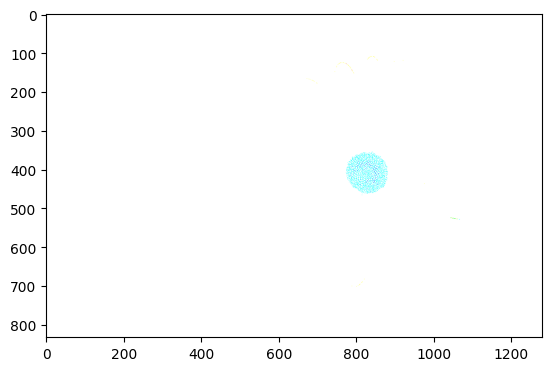

In [ ]:
plt.imshow(stretching_img)

Bit Plane Slicing

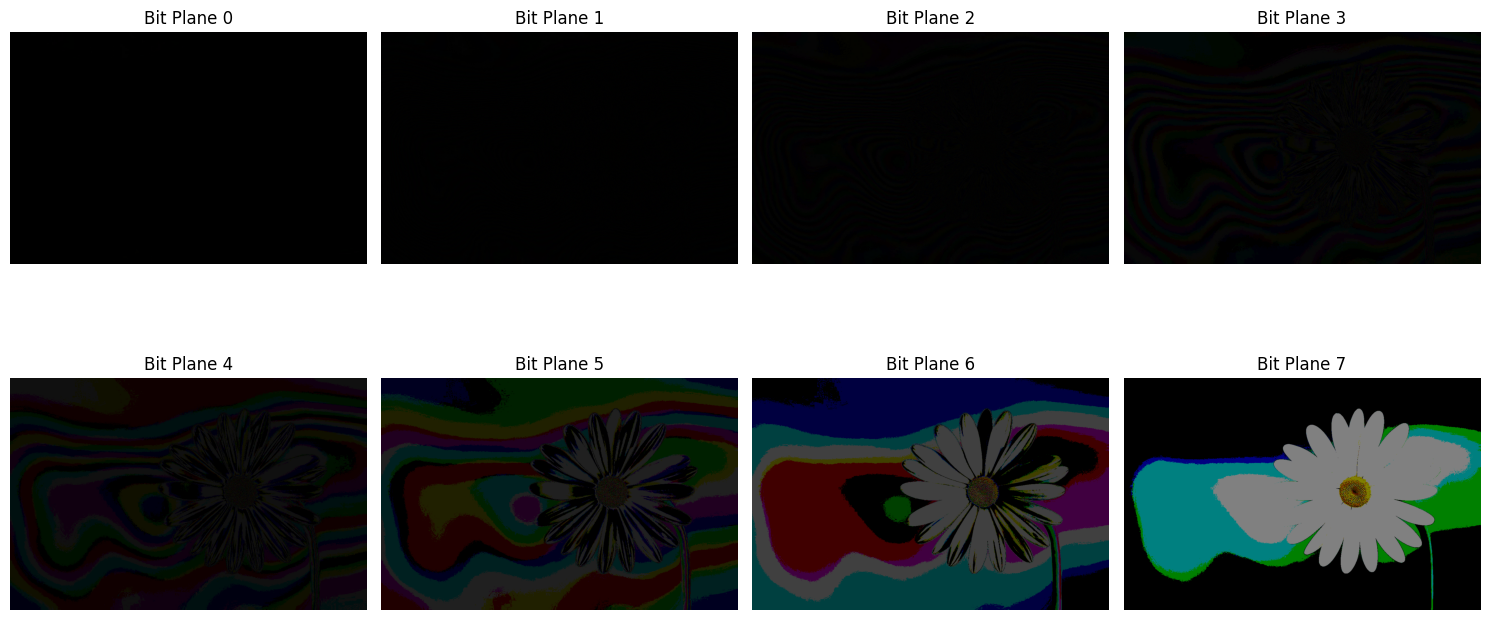

In [ ]:
plt.figure(figsize=(15, 8))
for k in range(8):
    # Calculate the k-th bit plane
    plane = np.full(img.shape, 2**k, dtype=np.uint8)
    bit_plane = cv2.bitwise_and(img, plane)

    # Display each bit plane in a subplot
    plt.subplot(2, 4, k + 1) # Create a 2x4 grid of subplots
    plt.imshow(cv2.cvtColor(bit_plane, cv2.COLOR_BGR2RGB)) # Convert to RGB for correct display
    plt.title(f'Bit Plane {k}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def gray_level_slicing(image, low_range, high_range, preserve_background=False):
    # Ensure image is grayscale
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image

    # Create an output image of the same size as the grayscale image
    output_image = np.zeros_like(image_gray, dtype=np.uint8)

    # Apply slicing
    if preserve_background:
        # Pixels within the range are set to 255, others remain their original gray value
        # For display, setting to 255 is more visible. If original gray value is needed,
        # a different approach like masking is better.
        output_image = image_gray.copy()
        output_image[(image_gray >= low_range) & (image_gray <= high_range)] = 255
    else:
        # Pixels within the range are set to 255, others to 0
        output_image[(image_gray >= low_range) & (image_gray <= high_range)] = 255

    return output_image

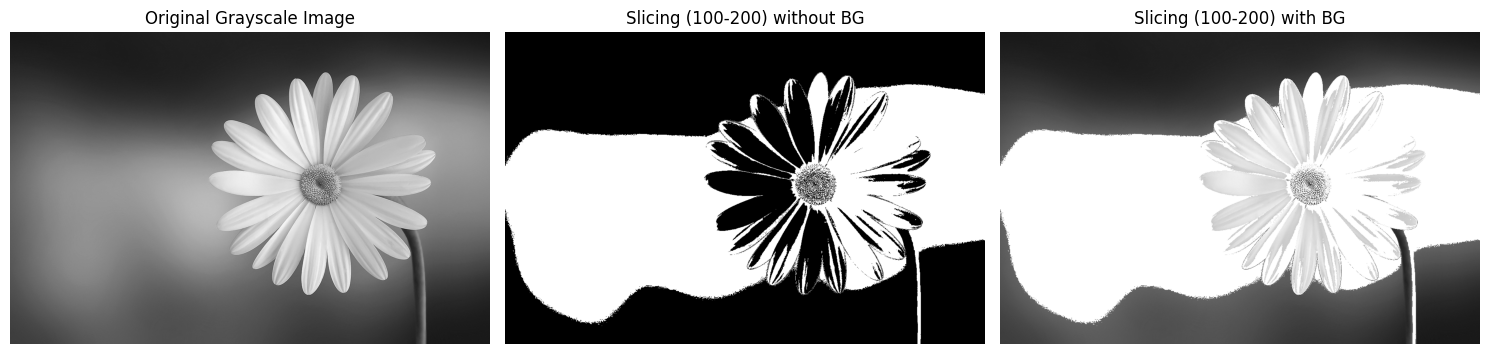

In [ ]:
# Convert the original image to grayscale first
img_gray_gls = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define the low and high range for slicing
low_range = 100
high_range = 200

# Apply gray level slicing without preserving background
img_without_bg = gray_level_slicing(img_gray_gls, low_range, high_range, preserve_background=False)

# Apply gray level slicing with preserving background
# For visualization, we'll make the sliced part bright and other parts original intensity
# Note: This implementation sets non-sliced parts to their original gray value
img_with_bg = gray_level_slicing(img_gray_gls, low_range, high_range, preserve_background=True)

# Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray_gls, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_without_bg, cmap='gray')
plt.title(f'Slicing ({low_range}-{high_range}) without BG')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_with_bg, cmap='gray')
plt.title(f'Slicing ({low_range}-{high_range}) with BG')
plt.axis('off')

plt.tight_layout()
plt.show()